In [30]:
! gdown 1_MWFfawwHk3ELPLnePszBHgrU1uzZzea

Downloading...
From (original): https://drive.google.com/uc?id=1_MWFfawwHk3ELPLnePszBHgrU1uzZzea
From (redirected): https://drive.google.com/uc?id=1_MWFfawwHk3ELPLnePszBHgrU1uzZzea&confirm=t&uuid=95244cdc-751e-4cee-a66e-9028c7a9c2b1
To: /content/Fraud.csv
100% 494M/494M [00:06<00:00, 74.1MB/s]


In [38]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# **DATASET VIEW**

In [39]:
df = pd.read_csv('/content/Fraud.csv')

In [40]:
fdf= df.copy()

In [41]:
fdf.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# **DATASET DESCRIPTION**

- `step` - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

- `type` - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

- `amount` - amount of the transaction in local currency.

- `nameOrig` - customer who started the transaction

- `oldbalanceOrg` - initial balance before the transaction

- `newbalanceOrig` - new balance after the transaction

- `nameDest` - customer who is the recipient of the transaction

- `oldbalanceDest` - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

- `newbalanceDest` - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

- `isFraud- - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

- `isFlaggedFraud` - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200000 in a single transaction.

# **DATA PREPROCESSING**

In [87]:
# Number of rows and columns in the Dataset.
print("Number of rows in the dataset:", fdf.shape[0])
print("Number of columns in the dataset:", fdf.shape[1])

Number of rows in the dataset: 6362620
Number of columns in the dataset: 14


In [42]:
fdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [88]:
# Checking null value
fdf.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [89]:
# Check for duplicate values
fdf.duplicated().sum()

np.int64(0)

# **EDA ON THE DATASET**

### Fraud vs Non-Fraud Distribution

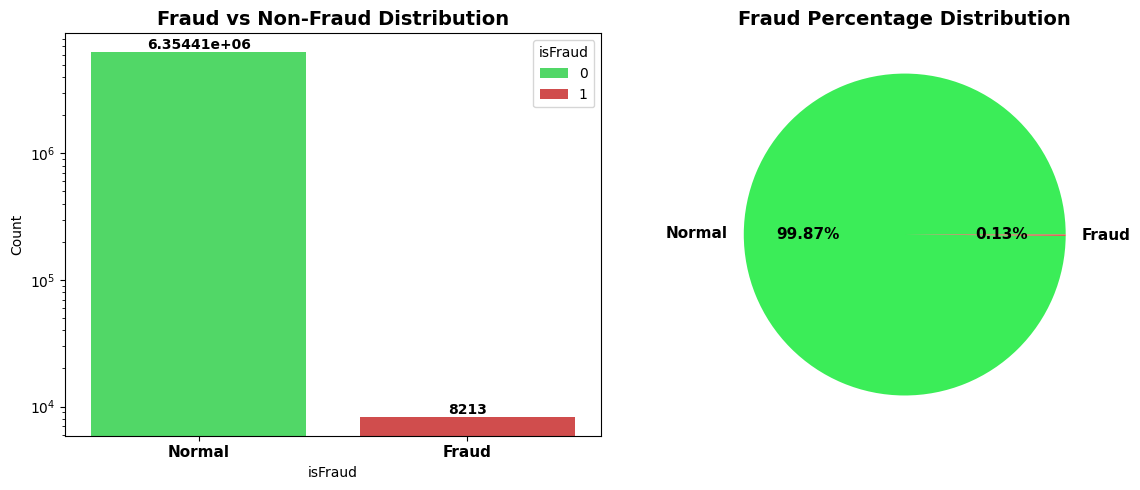

In [93]:
# Create subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color mapping
colors_map = {0: '#3BED58', 1: '#E63737'}

# Count Plot
sns.countplot(x='isFraud', data=fdf, hue='isFraud', ax=axes[0], palette=colors_map, order=[0, 1])
axes[0].set_yscale('log')
for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold')
axes[0].set_title('Fraud vs Non-Fraud Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Fraud'], fontsize=11, fontweight='bold')


# Pie Chart
value_counts = fdf['isFraud'].value_counts()
pie_colors = [colors_map[label] for label in value_counts.index]
pie_labels_map = {0: 'Normal', 1: 'Fraud'}
pie_labels = [pie_labels_map[label] for label in value_counts.index]

axes[1].pie(value_counts, labels=pie_labels, autopct='%1.2f%%', colors=pie_colors, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Fraud Percentage Distribution', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

The fraud vs non-fraud distribution shows that 6,354,407 transactions (99.87%) are non-fraudulent, while only 8,213 transactions (0.13%) are fraudulent. This clearly indicates that the dataset is highly imbalanced, with the majority class (non-fraud) significantly outweighing the minority class (fraud).

In such scenarios, machine learning models tend to become biased toward the majority class, which can lead to poor detection of fraudulent transactions. As a result, relying solely on accuracy as an evaluation metric can be misleading, since a model may achieve high accuracy simply by predicting most transactions as non-fraud.

Therefore, in this project, recall is given higher importance as the primary evaluation metric. Recall measures the model’s ability to correctly identify actual fraudulent transactions. A high recall ensures that most fraud cases are detected, minimizing the number of undetected fraudulent activities, which is critical in real-world financial systems.

### Transaction Type Distribution

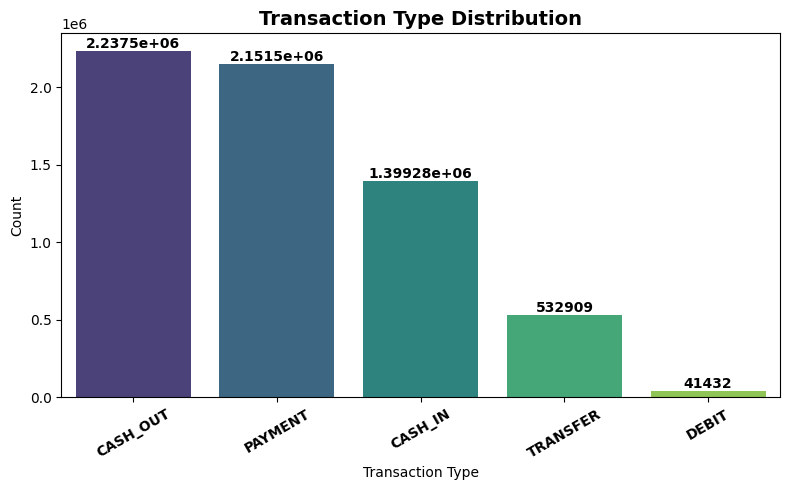

In [94]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='type', data=fdf, order=fdf['type'].value_counts().index, palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fontweight='bold'
plt.title('Transaction Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Count')

plt.xticks(rotation=30, fontweight='bold')
plt.tight_layout()
plt.show()

Most transactions are CASH_OUT and PAYMENT, indicating common financial activities, while TRANSFER and DEBIT are less frequent. However, fraud is mainly concentrated in TRANSFER and CASH_OUT transactions, making them critical for analysis.

### Fraud Transactions by Type

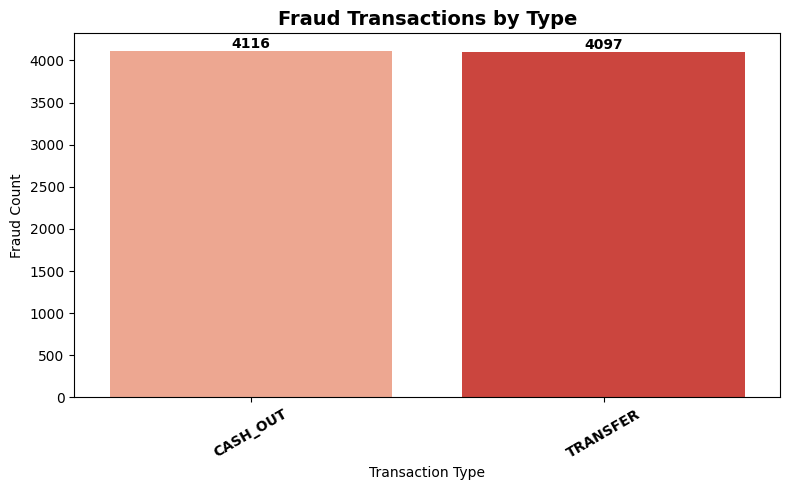

In [96]:
# Filter fraud data
fraud_df = fdf[fdf['isFraud'] == 1]

plt.figure(figsize=(8,5))
ax = sns.countplot(x='type', data=fraud_df, order=fraud_df['type'].value_counts().index, palette='Reds')
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')
plt.title('Fraud Transactions by Type', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Count')

plt.xticks(rotation=30, fontweight='bold')
plt.tight_layout()
plt.show()

Fraudulent transactions are observed only in TRANSFER and CASH_OUT types, with nearly equal counts. This reflects common fraud behavior, where money is transferred and then quickly withdrawn, making these transaction types crucial for detection.

# **FEATURE ENGINEERING**

In [51]:
fdf['errorOrig'] = fdf['oldbalanceOrg'] - fdf['amount'] - fdf['newbalanceOrig']
fdf['errorDest'] = fdf['oldbalanceDest'] + fdf['amount'] - fdf['newbalanceDest']

In [49]:
fdf['isMerchant'] = fdf['nameDest'].str.startswith('M').astype(int)

In [58]:
fdf.loc[fdf['isMerchant'] == 1, 'errorDest'] = 0

In [60]:
fdf[fdf['isMerchant'] == 1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,isMerchant,errorOrig,errorDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0.000000e+00,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0.000000e+00,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0.000000e+00,0.0
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,0,1,0.000000e+00,0.0
6,1,PAYMENT,7107.77,C154988899,183195.0,176087.23,M408069119,0.0,0.0,0,0,1,0.000000e+00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362312,718,PAYMENT,8178.01,C1213413071,11742.0,3563.99,M1112540487,0.0,0.0,0,0,1,0.000000e+00,0.0
6362314,718,PAYMENT,17841.23,C1045048098,10182.0,0.00,M1878955882,0.0,0.0,0,0,1,-7.659230e+03,0.0
6362316,718,PAYMENT,1022.91,C1203084509,12.0,0.00,M675916850,0.0,0.0,0,0,1,-1.010910e+03,0.0
6362318,718,PAYMENT,4109.57,C673558958,5521.0,1411.43,M1126011651,0.0,0.0,0,0,1,2.273737e-13,0.0


Two new features, `errorOrig` and `errorDest`, were created to capture inconsistencies in account balances.  Since merchant accounts lack destination balance information, a new feature isMerchant was introduced, and errorDest was set to zero for such cases. This prevents misleading values and improves fraud detection performance.

In a normal transaction, the sender’s balance should decrease exactly by the transaction amount, and the receiver’s balance should increase accordingly. Any deviation from this expected behavior may indicate suspicious or fraudulent activity, making these features highly useful for fraud detection.

# **SELECTING IMPORTANT FEATURE FOR PREDICTION**

In [66]:
transactions = fdf[['type', 'amount', 'errorOrig',	'errorDest', 'isFraud']]

In [67]:
transactions.head()

,type,amount,errorOrig,errorDest,isFraud
0,PAYMENT,9839.64,0.0,0.0,0
1,PAYMENT,1864.28,0.0,0.0,0
2,TRANSFER,181.00,0.0,181.0,1
3,CASH_OUT,181.00,0.0,21363.0,1
4,PAYMENT,11668.14,0.0,0.0,0


In [68]:
# Convert the categorical 'type' column into numerical form using one-hot encoding
# 'drop_first=True' avoids multicollinearity by removing one reference category
# 'dtype=int' ensures encoded values are 0 and 1 instead of True/False

transactions = pd.get_dummies(transactions, columns=['type'], drop_first=True, dtype=int)

In [69]:
transactions.head()

,amount,errorOrig,errorDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,0.0,0.0,0,0,0,1,0
1,1864.28,0.0,0.0,0,0,0,1,0
2,181.00,0.0,181.0,1,0,0,0,1
3,181.00,0.0,21363.0,1,1,0,0,0
4,11668.14,0.0,0.0,0,0,0,1,0


In [70]:
# Separate independent features (x) and target variable (y)
# x contains all input features used for prediction
# y contains the target variable 'isFraud' (0 = normal, 1 = fraud)

x = transactions.drop('isFraud', axis=1)
y = transactions['isFraud']

# **MODEL IMPLEMENTATION**

In [85]:
# Importing Libraries

from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score


In [75]:
# Split the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
# Initialize Balanced Random Forest model

brf = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [77]:
# Train the model on the training data
brf.fit(x_train, y_train)

BalancedRandomForestClassifier(n_jobs=-1, random_state=42)

In [78]:
# Predict fraud or non-fraud transactions for the test data
y_pred = brf.predict(x_test)

In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.05      0.99      0.10      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.98      0.54   1272524
weighted avg       1.00      0.98      0.99   1272524



In [84]:
print('accuracy', accuracy_score(y_test, y_pred))
print('recall', recall_score(y_test, y_pred))

accuracy 0.9766959208627892
recall 0.9914790018259282


# **RESULT**

The model achieved high recall (99.15%) for fraud detection, ensuring most fraudulent transactions are identified. However, precision is low (5%), indicating many false positives. This trade-off is acceptable in fraud detection, where minimizing missed fraud cases is more critical than avoiding false alarms.

# **CONCLUSION**

In this project, a machine learning-based approach was developed to detect fraudulent financial transactions using a highly imbalanced dataset. The analysis began with data understanding, cleaning, and exploratory data analysis, which revealed that fraudulent transactions constitute only 0.13% of the total data, highlighting a severe class imbalance problem.

To address this challenge, feature engineering was performed by creating meaningful variables such as errorOrig and errorDest, which capture inconsistencies in account balances. Additionally, a new feature isMerchant was introduced to handle missing balance information for merchant accounts, ensuring more accurate representation of transaction behavior.

A Balanced Random Forest Classifier was chosen as the primary model due to its ability to effectively handle imbalanced datasets without requiring synthetic data generation. Unlike traditional models, it balances the class distribution internally during training, improving the detection of minority class instances (fraud cases).

The model achieved a high recall of 99.15% for fraudulent transactions, indicating that it successfully identified the majority of fraud cases. While the precision was relatively low due to increased false positives, this trade-off is acceptable in fraud detection systems where minimizing missed fraud is more critical than reducing false alarms.